# Class 21: Partial Differential Equations

Ch. 9, sections 1-3: Partial Differential Equations 
- Boundary value problems and the relaxation method
    - Overview of faster methods for boundary value problems 
- Initial value problems
    - the FTCS method 

Complete the activities as instructed by the professor

#### Import any packages we need below (update as we go):

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import random 

### Partial Differential Equations 

Compute the solution to the two-dimensional electrostatics problem of Fig. 9.1 using the Jacobi method, for the case where the box is 1 m along each side, $V = 1$ volt, and the grid spacing $a=1$ cm, so that there are 100 grid points on a side, or 101 if we count the points at both the beginning and the end. Here's a program to calculate the solution and make a density plot of the result. 

Laplace's Equation: 
$$ \nabla^2 \phi = 0$$

Fig 9.1: 

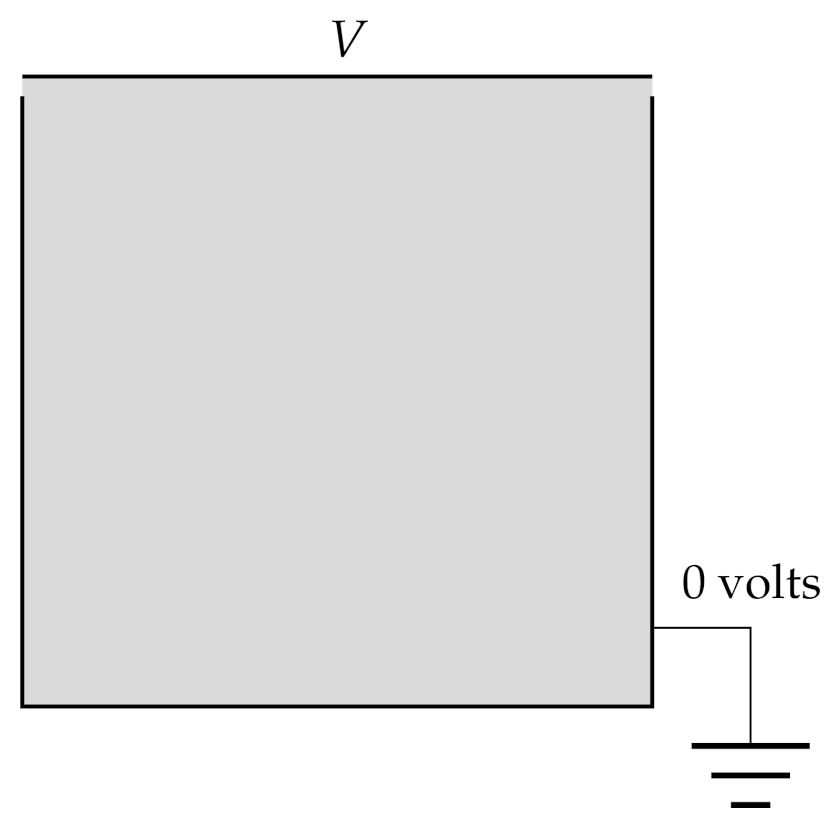

Reminder, the Laplacian operator is: $\nabla^2 = \frac{\partial^2 \phi}{\partial x^2} + \frac{\partial^2 \phi}{\partial y^2} + \frac{\partial^2 \phi}{\partial z^2} $

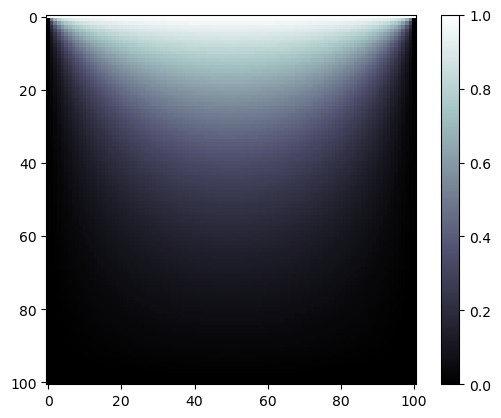

In [10]:
# define constants
M = 100 # grid squares on a side
V = 1.0 # voltage
L = 1.0 # length of side of box
a = L/M # size of actual grid box
target = 1e-6 # target accuracy for jacobi method

# create array to hold potential values
phi = np.zeros([M+1,M+1], float)
# apply boundary conditions
phi[0,:] = V
# define second phi array
phiprime = np.zeros([M+1,M+1], float)

# define initial max difference between arrays
delta = 1.0
# begin jacobi method loop
while delta > target:
    # calculate the new values of the potential
    for i in range(M+1):
        for j in range(M+1):
            if i == 0 or i == M or j == 0 or j == M:
                phiprime[i,j] = phi[i,j]
            else:
                phiprime[i,j] = (phi[i+1,j]+ phi[i-1,j]+ phi[i,j+1]+ phi[i,j-1])/4
    
    # check maximum difference from the old phi
    delta = np.max(np.abs(phi - phiprime))

    phi, phiprime = phiprime, phi

# make a density plot
plt.imshow(phi)
plt.bone()
plt.colorbar()
plt.show()


### Example 9.2 + Exercise 9.1: Solution of the Poisson Equation 

Let's consider the solution of the Poisson equation of electrostatics: 

$$ \nabla^2 \phi = -\frac{\rho}{\epsilon_0} $$

which governs the electric potential in the presence of a charge density $\rho$. Here $\epsilon_0$ is the permittivity of empty space (and we are assuming that we are in empty space). 

Let's consider the equation in two dimensions again, for simplicity, and again in a square box 1 meter long on each side. This time, however, all the walls of the box will be at voltage zero, but there are two square charges in the box, one positive, one negative, as shown in the figure below. The two charges are 20 cm on a side and 20 cm from the walls of the box and have charge density of $\pm 1$ $\text{Cm}^{-2}$. 

To solve for the electric potential in this system using the relaxation method, we combine our previous equation and the new Poisson's equation and then rearrange to get: 

$$ \phi(x,y) = \frac{1}{4}\left[ \phi(x+a,y) + \phi(x-a,y) + \phi(x,y+a) + \phi(x,y-a) \right] + \frac{a^2}{4\epsilon_0}\rho(x,y) $$

*Note that the spacing of the grid no longer drops out of the equation!*

Write a program, or modify the one from Example 9.1, to solve Poisson’s equation for the system described in Example 9.2. Work in units where $\epsilon_0 = 1$ and continue the iteration until your solution for the electric potential changes by less than $10^{−6}$ V per step at every grid point.

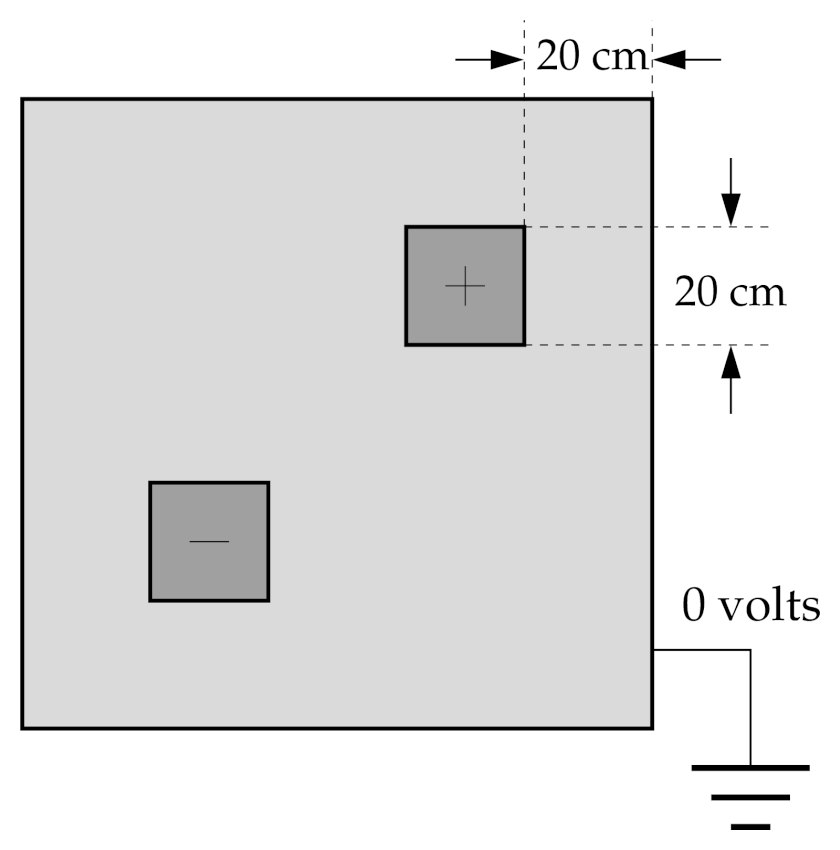


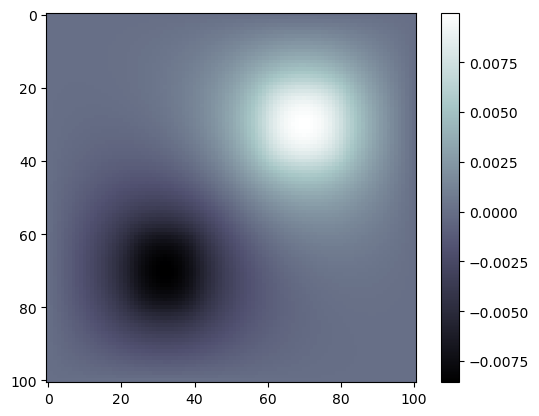

In [11]:
# define constants
M = 100 # grid squares on a side
V = 1.0 # voltage
L = 1.0 # length of side of box
a = L/M # size of actual grid box
epsilon0 = 1.0 # permitivity
rho0 = 1.0 # charge density of the charges
target = 1e-6 # target accuracy for jacobi method

# create array to hold potential values
phi = np.zeros([M+1,M+1], float)
# define second phi array
phiprime = np.zeros([M+1,M+1], float)
# define an array for charge densitites
rho = np.zeros([M+1,M+1], float)
rho[20:41,60:81] = rho0
rho[60:81, 24:41] = - rho0


# define initial max difference between arrays
delta = 1.0
# begin jacobi method loop
while delta > target:
    # calculate the new values of the potential
    for i in range(M+1):
        for j in range(M+1):
            if i == 0 or i == M or j == 0 or j == M:
                phiprime[i,j] = phi[i,j]
            else:
                phiprime[i,j] = (phi[i+1,j]+ phi[i-1,j]+ phi[i,j+1]+ phi[i,j-1] + rho[i,j]*a**2/epsilon0)/4
    
    # check maximum difference from the old phi
    delta = np.max(np.abs(phi - phiprime))

    phi, phiprime = phiprime, phi

# make a density plot
plt.imshow(phi)
plt.bone()
plt.colorbar()
plt.show()


### Fixed-Gradient (Neumann) Boundary Conditions 

**Steady State of the Heat Equation with Neumann Bounaries**

Thermal conduction is governed by the diffusion equation, also called the heat equation in this context 

$$ D \nabla^2 T = \frac{\partial T}{\partial t} $$

where $T({\bf{r}},t)$ is the temperature at location ${\bf{r}}$ and time $t$ and the constant $D$ is the thermal diffusivity. For a system that has reached a steady state, so that $\partial T/\partial t = 0$ everywhere, this gives us Laplace's equation again: 

$$\nabla^2 T = 0$$

so we can solve static thermal problems of this kind using the Jacobi method. 

Let us solve for the temperature profile in a two-dimensional system with same geometry as Fig. 9.4, but with the two electric charges replaced by square plates at fixed temperatures $T_1$ and $T_2$, and perfectly insulating walls, so that no heat can enter or leave. This means that Neumann boundary conditions aply: the perpendicular derivative of the temperature must be zero everywhere on the walls. 

Let's calculate and plot the temperature profile for this system with $T_1 = 0 \degree \text{C}$, $T_2 = 100 \degree \text{C}$ and thermal diffusivity $D = 10^{-6} \text{ m}^2\text{s}^{-1}$

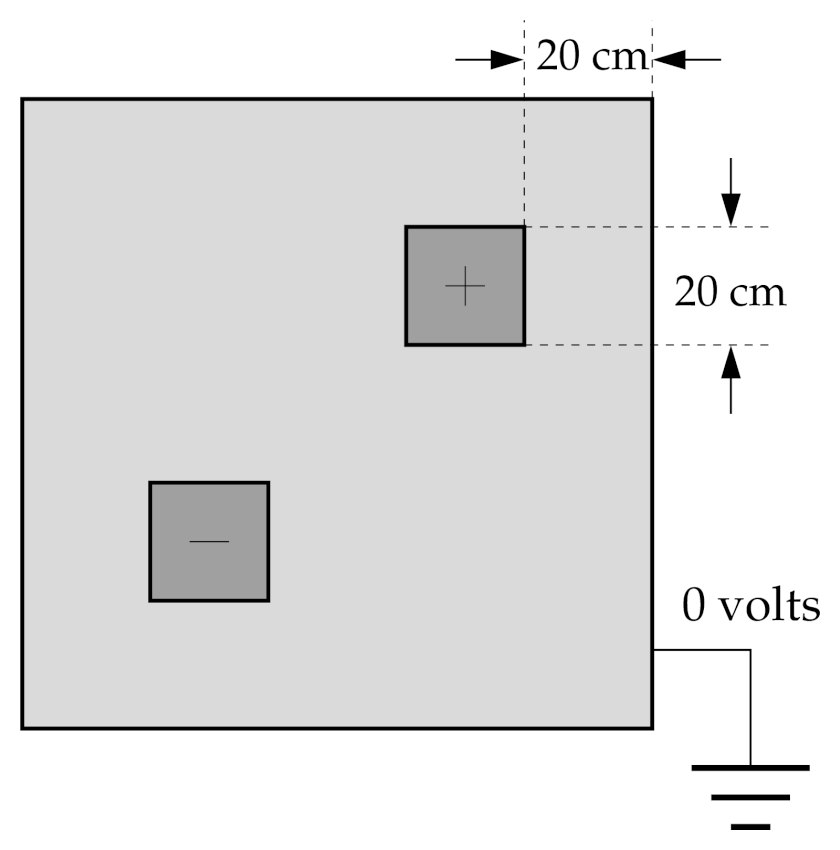

In [ ]:
# constants
L = 1.0
M = 100
D = 1e-6
T1,T2 = 0.0, 100.0

T = np.zeros([M+1,M+1], float)
for i in range(20,41):
    for j in range(60,81):
        T[i,j] = T1
        T[j,i] = T2
Tprime = np.zeros([M+1,M+1], float)

# main loop



### Initial value problems: the FTCS method

**Example 9.3**: The Heat Equation 

The flat base of a container made of 1 cm thick stainless steel is initially at a uniform temperature of $20^\circ$ C everywhere. The container is placed in a bath of cold water at $0^\circ$ C and filled with hot water at $50^\circ$ C. 

Our goal is to calculate the temperature profile of the steel as a function of distance $x$ from the hot side to the cold side, and as a function of time. For simplicity, let's treat the base of the container as being arbitrarily wide, so that its temperature profile is the same everywhere, and assume that neither the hot nor the cold water changes temperature appreciably. 

Thermal conduction is goverened by the diffusion equation, so solving this problem is a matter of solving the one-dimensional diffusion equation for the temperature $T$: 

$$ \frac{\partial T}{\partial t} = D \frac{\partial^2 T}{\partial x^2} $$

where $T$ is the temperature and $D$ is the heat diffusion coefficient, also called the thermal diffusivity. Let us divide the $x$-axis into 200 equal grid intervals, meaning that there will be 201 grid points in total, counting the first and last ones. The first and last points have fixed temperatures of $50^\circ$ C and $0^\circ$ C, respectively, while the intermediate points are initially all at $20^\circ$ C. We also need the heat diffusion coefficient for stainless steel (thermal diffusivity), which is $D = 4.25 \times 10^{-6}$ $\text{ m}^2\text{s}^{-1}$. 

We will calculate this using the FTCS method, and plot the temperature profile at times $t = 0.01, 0.1, 0.4, 1.0,$ and $10.0$ s all on the same graph. 

### Exercise 9.8: Thermal diffusion in the Earth's Crust

A classic example of a diffusion problem with a time-varying boundary condition is the diffusion of heat into the crust of the Earth, as surface temperature varies with the seasons. Suppose the mean daily temperature at a particular point on the surface varies as:

$$ T_0(t) = A + B\sin{\frac{2\pi t}{\tau}} $$

where $\tau = 365$ days, $A = 10^{\circ}\text{C}$ and $B = 12^{\circ}\text{C}$. At a depth of $20$ m below the surface almost all annual temperature variation is ironed out and the temperature is, to a good approximation, a constant $11^{\circ}\text{C}$ (which is higher than the mean surface temperature of $10^{\circ}\text{C}$—temperature increases with depth, due to heating from the hot core of the planet). The thermal diffusivity of the Earth’s crust varies somewhat from place to place, but for our purposes we will treat it as constant with value $D = 0.1\text{ m}^2\text{ day}^{−1}$.

Write a program, or modify one of the ones given in this chapter, to calculate the temperature profile of the crust as a function of depth up to $20$ m and time up to $10$ years. Start with temperature everywhere equal to $10^{\circ}\text{C}$, except at the surface and the deepest point, choose values for the number of grid points and the time-step $h$, then run your program for the first nine simulated years, to allow it to settle down into whatever pattern it reaches. Then for the tenth and final year plot four temperature profiles taken at 3-month intervals on a single graph to illustrate how the temperature changes as a function of depth and time.